# 📦 ML-->Unsupervised --> Clustering 

# 🎯 Maqsad: Mijozlarni xarid odatlariga qarab guruhlarga ajratish.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

# 💾 Dataset: Mall Customer Segmentation

In [3]:
import pyreadr
import pandas as pd 
df = pd.read_csv("Mall_Customers.csv")


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 🔍 Quyidagi jadvalda biz yosh va xarid faolligi bo`yicha malumotlar chizmasini ko`ramiz 

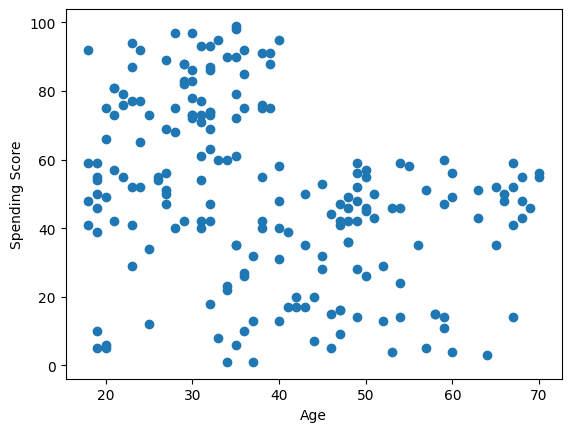

In [6]:
plt.scatter(df['Age'], df['Spending Score (1-100)'])
plt.xlabel('Age')
plt.ylabel('Spending Score')
plt.show()

# 📌 Ushbu ustun bizga nimalar beradi 
#Eng ko‘p xarid qiluvchilar qaysi yosh oralig‘ida?
#Yoshi katta yoki kichik bo‘lganlar ko‘proq xarid qiladimi?
#Mijozlar qanday guruhlarga ajratilishi mumkin?

# 🔍 Quyidagi jadvalda biz yosh va yillik daromad  bo`yicha malumotlar chizmasini ko`ramiz 

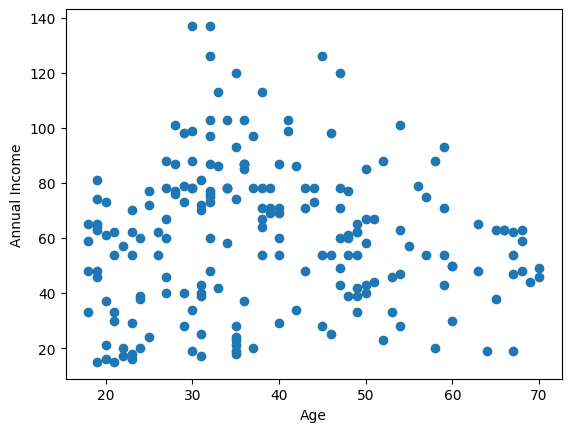

In [7]:
plt.scatter(df['Age'], df['Annual Income (k$)'])
plt.xlabel('Age')
plt.ylabel('Annual Income')
plt.show()

# 📌 Ushbu ustun bizga nimalar beradi 
#Qanday yoshdagi odamlar yuqori daromadga ega?
#Yosh bilan daromad o‘rtasida qanday bog‘liqlik bor?
#Mijozlar daromadi va yoshi bo‘yicha qanday segmentlarga ajralgan?

# 🔍 Quyidagi jadvalda biz yillik daromad va xarid qilish faolligi bo`yicha malumotlar chizmasini ko`ramiz 

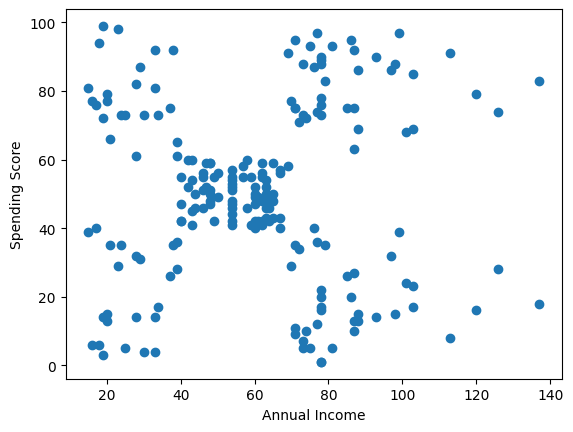

In [8]:
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.show()

# 📌 Ushbu ustun bizga nimalar beradi 
#Mijozlar daromadi va xarid qilish odatlari qanday bog‘liq?
#Kim ko‘p daromadga ega, lekin kam xarid qiladi?
#O‘rtacha daromadli, lekin yuqori xarid qiladiganlar kim?
#Klasterlash uchun eng mos 2D kombinatsiyalardan biri aynan shu grafik.

# 🧠 Elbow metodi 

In [14]:
sse = []
for i in range(1, 10):
    km = KMeans(n_clusters =  i)
    km.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    sse.append(km.inertia_)

In [15]:
sse

[269981.28,
 186687.04312531714,
 132162.13629759202,
 73679.78903948834,
 44448.45544793371,
 60145.71609540503,
 36699.25454478832,
 27486.954822827825,
 23941.9306274861]

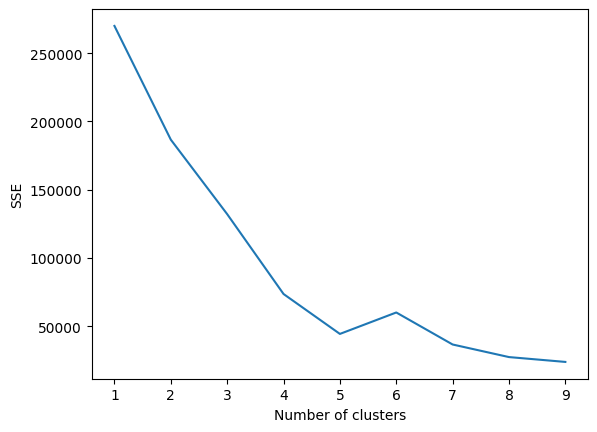

In [17]:
plt.xlabel('Number of clusters')
plt.ylabel("SSE")
plt.plot(range(1,10), sse)

In [18]:
km = KMeans(n_clusters = 5)
predicted = km.fit_predict(df[['Annual Income (k$)', 'Spending Score (1-100)']])
predicted

array([2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3,
       2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 3, 2, 0,
       2, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 4, 1, 4, 0, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 0, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4, 1, 4,
       1, 4], dtype=int32)

In [19]:
df['Cluster'] = predicted
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,3
2,3,Female,20,16,6,2
3,4,Female,23,16,77,3
4,5,Female,31,17,40,2
...,...,...,...,...,...,...
195,196,Female,35,120,79,4
196,197,Female,45,126,28,1
197,198,Male,32,126,74,4
198,199,Male,32,137,18,1


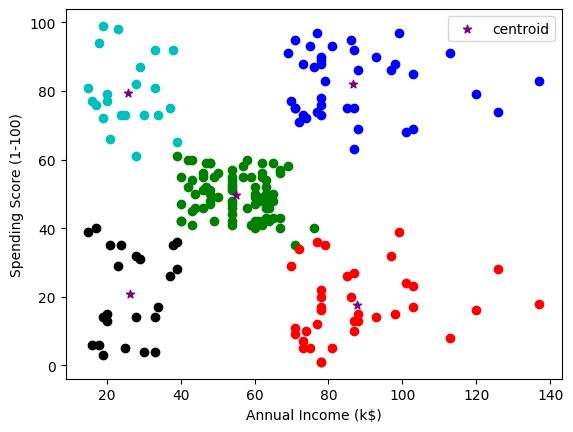

In [20]:
df1 = df[df.Cluster==0] 
df2 = df[df.Cluster==1] 
df3 = df[df.Cluster==2]
df4 = df[df.Cluster==3]
df5 = df[df.Cluster==4]

plt.scatter(df1['Annual Income (k$)'],df1['Spending Score (1-100)'],color='green')
plt.scatter(df2['Annual Income (k$)'],df2['Spending Score (1-100)'],color='red')
plt.scatter(df3['Annual Income (k$)'],df3['Spending Score (1-100)'],color='black')
plt.scatter(df4['Annual Income (k$)'],df4['Spending Score (1-100)'],color='c')
plt.scatter(df5['Annual Income (k$)'],df5['Spending Score (1-100)'],color='blue')

plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],
            color='purple',marker='*',label='centroid')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()

In [ ]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Spending Score (1-100)']

In [22]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

x = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)


In [23]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=42)
y = kmeans.fit_predict(x_scaled)


In [24]:
from sklearn.metrics import silhouette_score

for k in [4, 5]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(x)
    score = silhouette_score(x, labels)
    print(f"Silhouette Score for k={k}: {score:.3f}")


Silhouette Score for k=4: 0.494
Silhouette Score for k=5: 0.554


In [25]:
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)


y = kmeans.fit_predict(x)

In [26]:
print(y)

[4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4 2 4
 2 4 2 4 2 4 0 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 1 3 1 0 1 3 1 3 1 0 1 3 1 3 1 3 1 3 1 0 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3
 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1]


In [28]:
import pandas as pd
from sklearn.cluster import KMeans
df = pd.read_csv("Mall_Customers.csv") 
kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(df.select_dtypes(include='number')) 

for cluster_num in range(5):
    cluster_df = df[df['Cluster'] == cluster_num]
    filename = f'cluster_{cluster_num + 1}_Customer_dataset.csv'
    cluster_df.to_csv(filename, index=False)

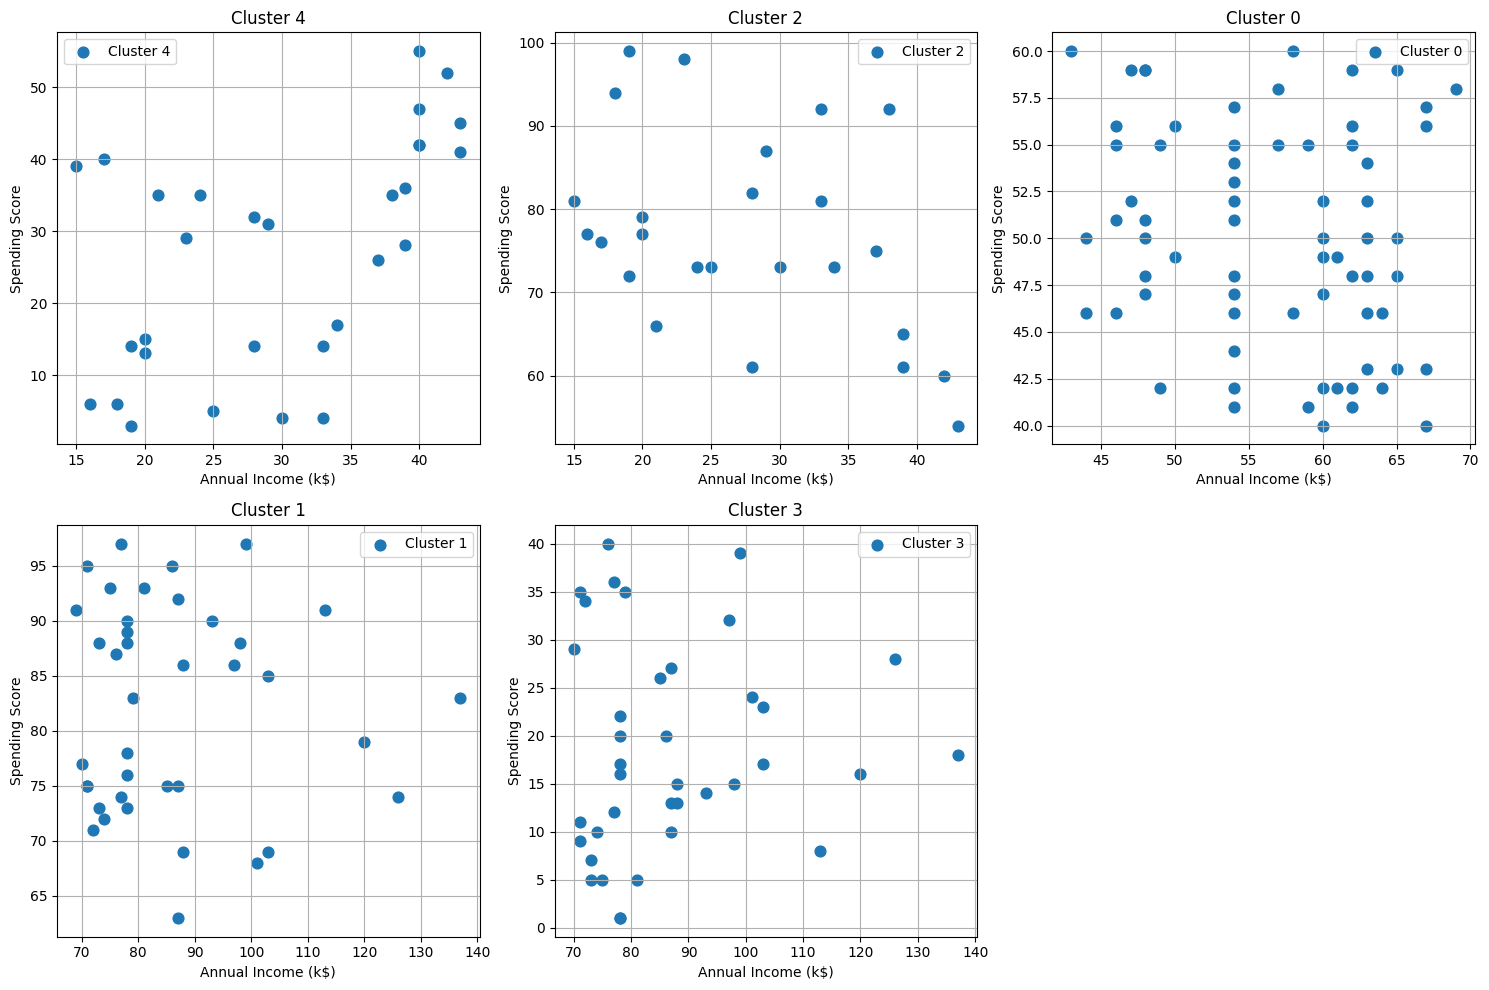

In [31]:
unique_clusters = df['Cluster'].unique()

plt.figure(figsize=(15, 10))
for i, cluster in enumerate(unique_clusters):
    plt.subplot(2, 3, i+1)  # subplotlar uchun joy ajratish (2 qator, 3 ustun)
    cluster_df = df[df['Cluster'] == cluster]
    plt.scatter(cluster_df['Annual Income (k$)'],
                cluster_df['Spending Score (1-100)'],
                s=60, label=f"Cluster {cluster}")
    plt.title(f"Cluster {cluster}")
    plt.xlabel("Annual Income (k$)")
    plt.ylabel("Spending Score")
    plt.legend()
    plt.grid(True)    


plt.tight_layout()
plt.show()


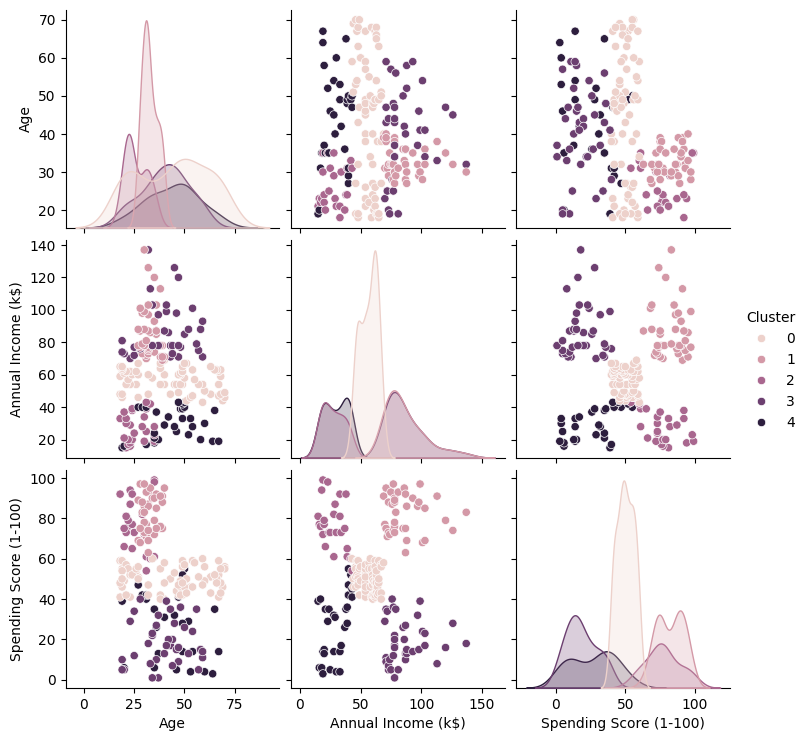

In [32]:
sns.pairplot(df, hue='Cluster', vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'])
plt.show()